### Model

A Model here consists of a succession of layers.

Each layer is implemented as a class with the following API-methods:

`forward(torch.tensor)`: Computes the forward pass through the layer (i.e. $x\rightarrow a$) and keeps the information needed for computing the backward pass as member variables. <br>
`backward(torch.tensor)`: Computes the backward pass through the layer in form of the derivatives (i.e. $da \rightarrow dx$). On the fly, it also computes the derivatives w.r.t. the parameters of the layer and keeps them as member variables. It assumes that the `forward`-method has been run before. <br>
`update(lr)`: Updates the parameters of the layer in accordance with vanilla gradient descent and scalar learning rate `lr`. It assumes that the `forward` and the `backward`-pass has been run before.  

The tensors defined as inputs to the `forward`/`backward`-method are two dimensional with the sample index (within batch) in the first and the the feature index in the second dimension. We consider the raw data to be 1d (e.g. a greyscale image representated as 1d array).  

For fully connected layers with activation function $s(\cdot)$ the formulas are given as follows:

__Forward path:__

$X_{i,j}$: Tensor with shape $(n_b,n_x)$ where $n_b$ is the number of samples in the batch and $n_x$ the number of input features (for MNIST: 784).

$Z_{i,j} = \sum_k X_{i,k} W_{j,k} + b_j \qquad {\rm or }\qquad Z = X \cdot W^T + b$ $\qquad$ ($W$ a tensor of shape $(n_h,n_x)$)

$A_{i,j} = s(Z_{i,j}) \qquad\qquad\qquad {\rm or } \qquad A = s(Z)$




__Backward path:__ (with $n_b$ the number of samples in a batch)

$dX_{i,k} = \frac{\partial L}{\partial X_{i,k}} = \sum_j \frac{\partial L}{\partial A_{i,j}} \frac{\partial A_{i,j}}{\partial X_{i,k}} = \sum_j dA_{i,j} \, s^\prime(Z_{i,j})\, \frac{\partial Z_{i,j}}{\partial X_{i,k}} = \sum_j dA_{i,j} \, s^\prime(Z_{i,j}) \,W_{j,k}$<br>

$dW_{j,k} = \frac{\partial L}{\partial W_{j,k}} = \frac{1}{n_b}\sum_{i,l} dA_{i,l}\frac{\partial A_{i,l}}{\partial W_{j,k}} = \frac{1}{n_b}\sum_{i,l} dA_{i,l} s^\prime(Z_{i,l}) \delta_{j,l} X_{i,k} = \frac{1}{n_b}\sum_{i} dA_{i,j} s^\prime(Z_{i,j}) X_{i,k} $<br>




__Parameter Initialisation__

The parameters need to be initialised which will be a topic later in the course. For now use the following rules:
* weights normally distributed with mean $0$ and stdev $1/\sqrt{n_h}$
* bias initialized with zero values

#### <span style="color:red">Important Note on the Implementation</span>

Make sure that all the tensors used anywhere in the model components below have `requires_grad=False`.
Autograd functionality is not allowed for computing the gradients. - Autograd will be used below for testing whether your implementation is correct.

In [ ]:
import math
import numpy as np
import torch
import torchvision

### Linear Layer

In [ ]:
class LinearLayer():
    def __init__(self, nx, nh):
        """
        nx -- number of input features, i.e. shape of input tensors x given by (*,nb_input)
        nh -- number of output features, i.e. shape of output tensor z given by (*,nb_hidden)
        """
        self.nx = nx
        self.nh = nh
        self.w = torch.empty(nh, nx).normal_(0, 1./math.sqrt(self.nh))
        self.b = torch.zeros(nh)
        self.dw = torch.zeros_like(self.w)
        self.db = torch.zeros_like(self.b)
        self.x = None
        self.dx = None

    def forward(self, x):
        """
        Computes the forward pass through the layer
        x -- input tensor
        returns z
        """
        ### YOUR CODE START ###
        self.x = x
        return x @ self.w.T + self.b

        ### YOUR CODE END ###

    def backward(self, dz):
        """
        Computes the backward pass through the layer incl. the derivatives w.r.t. input x (dx), weight w (dw) and bias b (db).
        dz -- tensor with the backprop'd error signal with the same shape as z.
        returns dx
        """
        assert len(dz.shape)==2 and dz.shape[1] == self.nh
        ### YOUR CODE START ###
        self.dw = dz.T @ self.x     # shape : (nh, nx) because shape dz : (nb, nh) so shape dz.T : (nh, nb) and shape x : (nb, nx)
        self.db = dz.sum(dim=0)     # shape : (nh,)
        self.dx = dz @ self.w       # shape : (nb, nh) because shape dz : (nb, nh) and shape w : (nh, nx)
        return self.dx
        ### YOUR CODE END ###

    def update(self, lr):
        """
        Updates the parameters of the model (weights w and bias b) with the gradient w.r.t. w and b and learning rate.
        returns None
        """
        ### YOUR CODE START ###
        self.w = self.w - lr * self.dw
        self.b = self.b - lr * self.db
        ### YOUR CODE END ###



<span style="color:blue">SHAPE TEST:</span>

In [ ]:
linear = LinearLayer(3,4)
assert (4,3) == linear.w.shape
assert (4,)  == linear.b.shape

x = torch.tensor([[1.,2,3],[4,5,6]])
a = linear.forward(x)
assert (2,4) == a.shape

dz = torch.tensor([[1.,1,1,1],[2.,2,2,2]])
dx = linear.backward(dz)
assert (2,3) == dx.shape
assert (4,3) == linear.dw.shape

The shapes are consistent.

### Activation Function

__Sigmoid__

In [ ]:
class SigmoidActivation():

    def __init__(self):
        self.z = None

    def forward(self, z):
        ### YOUR CODE START ###
        self.z = z
        return 1 / (1 + torch.exp(-z))
        ### YOUR CODE END ###

    def backward(self, da):
        ### YOUR CODE START ###
        sigmoid = 1 / (1 + torch.exp(-self.z))
        dz = da * sigmoid * (1 - sigmoid)   # chain rule
        return dz

        ### YOUR CODE END ###

    def update(self, lr):
        ### YOUR CODE START ###
        pass # no parameters to update
        ### YOUR CODE END ###


### Model

Now implement an MLP as a succession of layers - linear layers and non-linear activation layers.
For creating an instance, you will pass the following arguments:
* nx: number of input features
* nunits: list of number of units in the hidden layers including the output layer

Add a list of layers as member variable.

Use just a linear layer at the end. Further below we will use a CE loss which is based on the finally output logit values (see lecture of week 2) where the softmax probabilities are implicit.

In [ ]:
class MLP():

    def __init__(self, nx, nunits):
        self.nx = nx
        self.nlayers = len(nunits)
        self.nunits = nunits
        self.nunits.insert(0,nx)
        self.nclasses = self.nunits[-1]
        self.layers = []

        ### YOUR CODE START ###
        # instantiate the different layers (linear and activations)
        for i in range(0, len(self.nunits)-2):
            self.layers.append(LinearLayer(self.nunits[i], self.nunits[i+1]))
            self.layers.append(SigmoidActivation())
        self.layers.append(LinearLayer(self.nunits[-2], self.nunits[-1]))
        # no sigmoid at the end
        ### YOUR CODE END ###


    def forward(self, x):
        """
        x - input tensor
        returns output tensor of the model
        """

        ### YOUR CODE START ###
        output = x
        for l in self.layers:
            output = l.forward(output)
        return output
        ### YOUR CODE END ###

    def backward(self, dy):
        """
        dy - derivative w.r.t. output tensor

        returns derivative with respect to the input tensor of the model;
        on the fly compute all the derivatives w.r.t. parameters of the model
        """
        ### YOUR CODE START ###
        grad = dy
        for l in reversed(self.layers):
            grad = l.backward(grad)
        return grad

        ### YOUR CODE END ###

    def update(self, lr):
        """
        Update the parameters with the given (stored) derivatives w.r.t. model parameters by using the given learning rate.
        """
        ### YOUR CODE START ###
        for l in self.layers:
            l.update(lr)



        ### YOUR CODE END ###


<span style="color:blue">SHAPE TEST:</span>

In [ ]:
nx = 2
nunits = [3,4]
mlp = MLP(nx,nunits)
assert 3 == len(mlp.layers)

x = torch.tensor([[1.,2],[3,4]])
a = mlp.forward(x)
assert (2,4) == a.shape

da = torch.tensor([[1.,1,1,1],[2.,2,2,2]])
dx = mlp.backward(da)
assert (2,2) == dx.shape

nx = 2
nunits = [3,4]
mlp = MLP(nx,nunits)
assert 3 == len(mlp.layers)

x = torch.tensor([[1.,2],[3,4]])
a = mlp.forward(x)
assert (2,4) == a.shape

da = torch.tensor([[1.,1,1,1],[2.,2,2,2]])
dx = mlp.backward(da)
assert (2,2) == dx.shape

The shapes are consistent.

### Regression Test

Create a regression testing that allows you to test your implementation by regressing against the gradients computed by pytorch's autograd.

Below you find two functions that may be helpful:
1. creating a reference model from the given model - makes sure that in the reference model the exact same initialized parameters are used; furthermore, that the parameters of the linear layers (w,b) are specified as tensors with `requires_grad=True`.
2. comparing the derivatives w.r.t. parameters for model and refmodel. It assumes that for both, model and refmodel, backprop has been executed. For the model, it means that `backward()`has been executed - for the ref model, only `forward` has been executed, but `backward` applied to the output tensor of the refmodel. For the remodel, we use `grad` of the weights and bias tensors, for the model the parameters `dw` and `db` as basis for the comparison.

<span style="color:red">Adjust these methods to make them compliant with your model - it uses internals of our implementation.</span>

In [ ]:
def create_refmodel(model):
    refmodel = MLP(model.nx, model.nunits[1:])
    for i,layer in enumerate(model.layers):
        if isinstance(layer, LinearLayer):
            refmodel.layers[i].w = model.layers[i].w.detach().clone()
            refmodel.layers[i].w.requires_grad_()
            refmodel.layers[i].b = model.layers[i].b.detach().clone()
            refmodel.layers[i].b.requires_grad_()
    return refmodel

def test_params(model, refmodel, digits=8):
    for i,layer in enumerate(model.layers):
        if isinstance(layer, LinearLayer):
            try:
                xxref = refmodel.layers[i].w.grad.detach().numpy()
                xx = model.layers[i].dw.numpy()
                np.testing.assert_array_almost_equal(xx, xxref, decimal=digits, err_msg="Error: layer %i"%i)
                xxref = refmodel.layers[i].b.grad.detach().numpy()
                xx = model.layers[i].db.numpy()
                np.testing.assert_array_almost_equal(xx, xxref, decimal=digits, err_msg="Error: layer %i"%i)

            except Exception as e:
                print("test failed - reason:",e)


<span style="color:blue"> REGRESSION TEST</span>

In [ ]:
# inputs
nx = 10
x = torch.randn(nx).reshape(-1,nx)
print(x.shape)

# model instance
nunits = [20,40,1]
mlp = MLP(nx,nunits)

# forward and backward pass
z = mlp.forward(x)
print(z.shape)
dz = torch.tensor([1.]).reshape(-1,1)
print(dz.shape)
dx = mlp.backward(dz)

# create ref model
mlpref = create_refmodel(mlp)

# only use the forward method of the ref model - and apply backward to the output tensor.
zref = mlpref.forward(x)
zref.backward()

# compare the derivatives computed by your model with the grad computed by pytorch's autograd
test_params(mlp, mlpref, digits=7)

torch.Size([1, 10])
torch.Size([1, 1])
torch.Size([1, 1])


> The function ```test_params``` passed : the model and refmodel are equal. We succeeded to compute correct gradients without the mechanism of ```autograd``` by PyTorch and retrieve the same results.

### Cost

Use the cross-entropy cost function directly defined on the basis of the logits - which implicitly includes a softmax calculation (see lecture notes of week 2).

In [ ]:
class CELoss():

    def value(self, z, y):
        """
        z -- tensor of shape (number of samples, number of classes) with the final logits of the model.
        y -- tensor of shape (number of samples) with the label values.
        """
        ### YOUR CODE START ###
        N = y.shape[0]
        proba = torch.softmax(z, dim = 1)
        p_correct = proba[torch.arange(N), y]
        return -torch.log(p_correct).mean()

        ### YOUR CODE END ###

    def derivative(self, z, y):
        ### YOUR CODE START ###
        N = y.shape[0]
        proba = torch.softmax(z, dim = 1)
        proba[torch.arange(N), y] -= 1
        return proba / N

        ### YOUR CODE END ###



In [ ]:
loss = CELoss()
ypred = torch.log(torch.tensor([[0.5,0.4,0.1],[0.2,0.1,0.7]])).reshape(-1,3) # -> logits z
y = torch.tensor([1,2]).reshape(-1)
np.testing.assert_almost_equal(loss.value(ypred,y), -torch.log(torch.tensor([0.4,0.7])).sum(), decimal=8)
np.testing.assert_array_almost_equal(loss.derivative(ypred,y), torch.tensor([[ 0.5000, -0.6000,  0.1000],[ 0.2000,  0.1000, -0.3000]]), decimal=8)

AssertionError: 
Arrays are not almost equal to 8 decimals

Mismatched elements: 6 / 6 (100%)
Max absolute difference: 0.3
Max relative difference: 0.50000006
 x: array([[ 0.25      , -0.3       ,  0.05      ],
       [ 0.09999999,  0.05      , -0.15      ]], dtype=float32)
 y: array([[ 0.5, -0.6,  0.1],
       [ 0.2,  0.1, -0.3]], dtype=float32)

### Load Data

As in previous' week PW.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [ ]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

### Training Loop

Implement mini-batch gradient descent training loop.

With the implementation of the two methods below you will be able to train and test the MLP:
* train_epoch: for training the model over one epoch with per mini-batch updates
* test_epoch: for evaluating the test/validation performance per epoch.

In [ ]:
def train_epoch(model, loss, dataloader, lr):
    """
    Iterate over the mini-batches of one epoch, compute per mini-batch the forward and backward pass
    and update the parameters. Also compute the loss and accuracy as an average over the epoch.
    Note that this average includes per mini-batch updated model predictions and parameter updates.
    model -- model to be trained
    loss -- loss function to be used
    dataloader -- data loader that provides mini-batches (from the training set)
    lr -- learning rate to be used in the parameter updates
    returns loss, accuracy
    """
    ### YOUR CODE START ###
    nsamples = len(dataloader.dataset)
    trainloss, correct = 0.0, 0
    for X, y in dataloader:
        batchsize = X.shape[0]
        X = X.view(batchsize, -1)
        z = model.forward(X)
        batchloss = loss.value(z, y)
        trainloss += batchloss.item()

        correct += (z.argmax(dim=1) == y).type(torch.float).sum().item()

        # Backpropagation
        dz = loss.derivative(z,y)
        dx = model.backward(dz)
        model.update(lr)
    trainloss /= nsamples
    correct /= nsamples
    return trainloss, correct
    ### YOUR CODE START ###


def test_epoch(model, loss, dataloader):
    """
    Iterate over the mini-batches of one epoch of the test set. Iterates over the mini-batches of the test set.
    Estimates loss and accuracy as an average over the test (validation) set. The model is not updates here.
    model -- model to be evaluated
    loss -- loss function to be evaluated
    dataloader -- data loader that provides mini-batches (from the test/validation set)
    returns loss, accuracy
    """
    nsamples = len(dataloader.dataset)
    testloss, correct = 0.0, 0
    for X, y in dataloader:
        batchsize = X.shape[0]
        X = X.view(batchsize, -1)
        z = model.forward(X)
        testloss += loss.value(z, y)
        correct += (z.argmax(dim=1) == y).type(torch.float).sum().item()

    testloss /= nsamples
    correct /= nsamples
    return testloss, correct


### First Simple Check: Overfitting on Single Sample

Load an arbitrary mini-batch from the training set. Train the model by using just this mini-batch.
This is another test for checking whether your implementation is capable of learning something (see remark in week 2 of the course).

In [ ]:
sample_batch, _ = torch.utils.data.random_split(train_data, [64, 60000-64])
train_loader = DataLoader(sample_batch, batch_size=64, shuffle=False) # shuffling not needed since only one batch is used.

sample_x,sample_y = next(iter(train_loader))
print(sample_x.shape,sample_y.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [ ]:
epochs = 100
lr = 0.01 #1.0
mlp = MLP(28*28, [100, 10])
mseloss = CELoss()
trainlosses = []
trainaccs = []
for t in range(epochs):
    trainloss, trainacc = train_epoch(mlp, mseloss, train_loader, lr)
    trainlosses.append(trainloss)
    trainaccs.append(trainacc)
    if t%10==0:
        print(f"Epoch: {t}, Train Accuracy: {(100*trainacc):>0.1f}%, Train Loss: {trainloss:>8f}")


Epoch: 0, Train Accuracy: 10.9%, Train Loss: 0.066920
Epoch: 10, Train Accuracy: 7.8%, Train Loss: 0.054179
Epoch: 20, Train Accuracy: 9.4%, Train Loss: 0.046873
Epoch: 30, Train Accuracy: 21.9%, Train Loss: 0.042011
Epoch: 40, Train Accuracy: 31.2%, Train Loss: 0.038384
Epoch: 50, Train Accuracy: 34.4%, Train Loss: 0.035356
Epoch: 60, Train Accuracy: 35.9%, Train Loss: 0.032712
Epoch: 70, Train Accuracy: 37.5%, Train Loss: 0.030433
Epoch: 80, Train Accuracy: 39.1%, Train Loss: 0.028544
Epoch: 90, Train Accuracy: 46.9%, Train Loss: 0.027020


Text(0.5, 1.0, 'Train Accuracy')

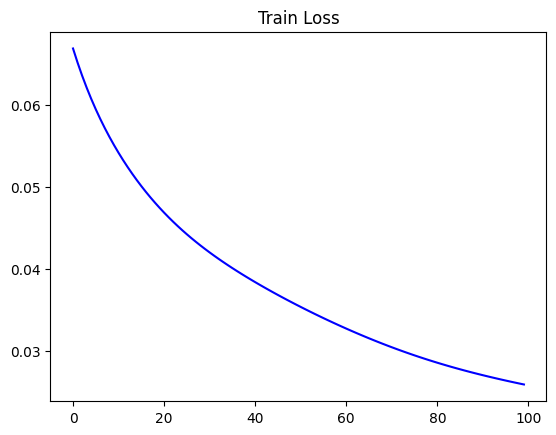

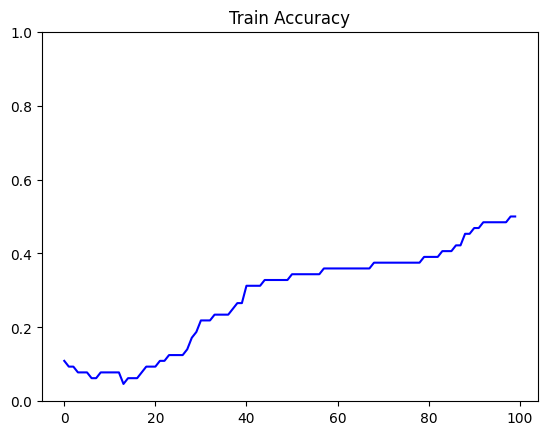

In [ ]:
plt.figure(1)
plt.plot(torch.arange(epochs), trainlosses,"b-")
plt.title("Train Loss")

plt.figure(2)
plt.plot(torch.arange(epochs), trainaccs,"b-")
plt.ylim([0.0,1])
plt.title("Train Accuracy")

>The **learning rate** was decreased from 1.0 to 0.01 to allow a smoother training. Futhermore, the ```value``` of the ```CELoss``` requiered a ```.mean()```  and not ```.sum()``` to decrease over time, and to not accumulate proportionnaly to N. However, the following cell of this notebook waits for the ```.sum()``` to fulfill the asserations.

>We can now reach an accuracy of **46.9%**. With ```batch_size = 64``` we might see some overfitting : the model learns those 64 example instead of generalizing.

### Training with all the training set

In [ ]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

In [ ]:
epochs = 10
lr = 1.0
mlp = MLP(28*28, [100,10])
mseloss = CELoss()
trainlosses, testlosses = [],[]
trainaccs, testaccs = [],[]

for epoch in range(epochs):
    trainloss, trainacc = train_epoch(mlp, mseloss, train_loader, lr)
    testloss, testacc = test_epoch(mlp, mseloss, test_loader)
    trainlosses.append(trainloss)
    testlosses.append(testloss)
    trainaccs.append(trainacc)
    testaccs.append(testacc)
    print(f"Epoch: {epoch}, Train Accuracy: {(100*trainacc):>0.1f}%, Train Loss: {trainloss:>8f}, Test Accuracy: {(100*testacc):>0.1f}%, Test Loss: {testloss:>8f}")

Epoch: 0, Train Accuracy: 90.7%, Train Loss: 0.005108, Test Accuracy: 94.4%, Test Loss: 0.002916
Epoch: 1, Train Accuracy: 95.5%, Train Loss: 0.002436, Test Accuracy: 95.8%, Test Loss: 0.002157
Epoch: 2, Train Accuracy: 96.7%, Train Loss: 0.001775, Test Accuracy: 96.5%, Test Loss: 0.001692
Epoch: 3, Train Accuracy: 97.4%, Train Loss: 0.001404, Test Accuracy: 97.2%, Test Loss: 0.001420
Epoch: 4, Train Accuracy: 97.9%, Train Loss: 0.001153, Test Accuracy: 97.4%, Test Loss: 0.001316
Epoch: 5, Train Accuracy: 98.2%, Train Loss: 0.000976, Test Accuracy: 97.4%, Test Loss: 0.001278
Epoch: 6, Train Accuracy: 98.5%, Train Loss: 0.000837, Test Accuracy: 97.4%, Test Loss: 0.001306
Epoch: 7, Train Accuracy: 98.7%, Train Loss: 0.000729, Test Accuracy: 97.7%, Test Loss: 0.001124
Epoch: 8, Train Accuracy: 98.9%, Train Loss: 0.000635, Test Accuracy: 97.7%, Test Loss: 0.001138
Epoch: 9, Train Accuracy: 99.0%, Train Loss: 0.000559, Test Accuracy: 97.9%, Test Loss: 0.001031


Text(0.5, 1.0, 'Accuracy')

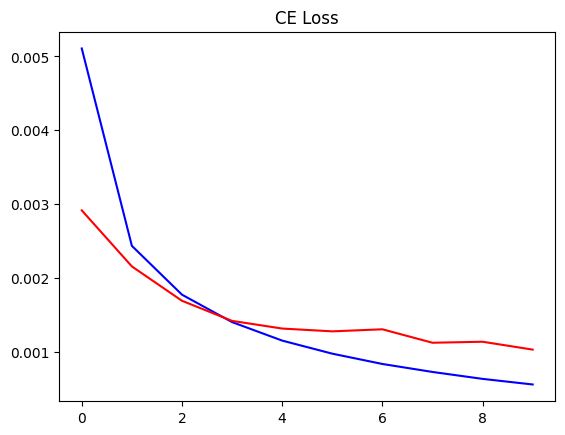

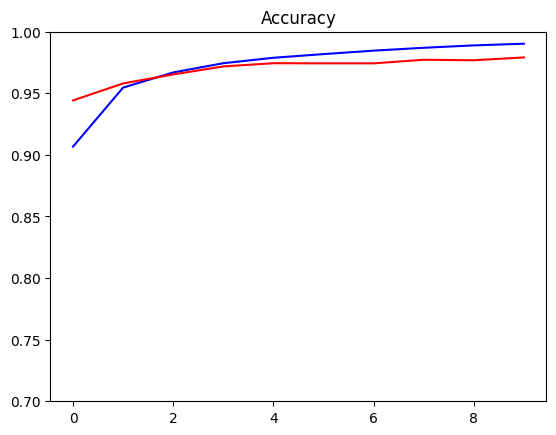

In [ ]:
plt.figure(1)
plt.plot(torch.arange(epochs), trainlosses,"b-")
plt.plot(torch.arange(epochs), testlosses,"r-")
plt.title("CE Loss")

plt.figure(2)
plt.plot(torch.arange(epochs), trainaccs,"b-")
plt.plot(torch.arange(epochs), testaccs,"r-")
plt.ylim([0.7,1])
plt.title("Accuracy")



>The performance of this model is similar to the one obtained in PW03. During this pratical work, we achieved having around **95%** of accuracy. Here, we can that the MLP model ends with a test accuracy of **97.9%**.
